**Recommender systems** are widely used to personalize content and assist users in discovering relevant items or connections. In the context of online dating platforms, recommender systems aim to suggest potential matches by modeling user preferences and interaction patterns, helping users discover compatible profiles efficiently.

A dataset derived from a dating application is provided, containing user–user interaction data that reflects expressed interest between profiles. **The goal of this task is to predict potential matches between users**, leveraging historical interactions to learn patterns of mutual preference. The system captures relationships between users in order to generate personalized match recommendations.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score as accuracy_skl
from sklearn.metrics import classification_report
from scipy.sparse import csr_matrix
from sklearn.model_selection import KFold

### Data loading

In [3]:
# Load the data
train_data = np.load('Resources/train_data.npy')
test_data = np.load('Resources/test_data.npy')
val_data = np.load('Resources/val_data.npy')

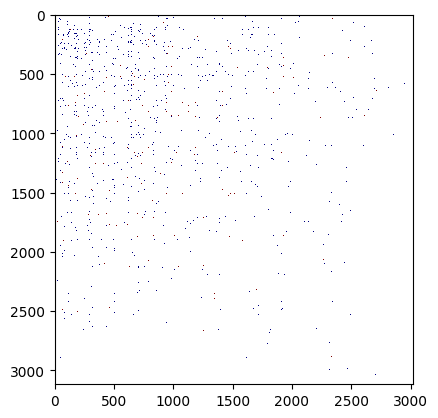

In [4]:
# Visualize the [user x user] arrays
cmap = cm.jet
cmap.set_bad('white',1.)

masked_array_train = np.ma.array(train_data, mask=np.isnan(train_data))
plt.imshow(masked_array_train, interpolation='nearest', cmap=cmap)
plt.pause(0.1)

In [9]:
print(train_data.shape)
print(val_data.shape)
print(test_data.shape)
print(np.nansum(train_data != val_data))
print(np.nansum(train_data != test_data))
print(train_data[10, :100])
print(val_data[10, :100])

(3118, 3018)
(3118, 3018)
(3118, 3018)
9410124
9410124
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan  0. nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan  1. nan nan
 nan nan nan nan nan nan nan nan  0. nan]
[nan nan nan nan nan nan nan nan nan nan  0. nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan]


### Familiarization

    1. What properties of the data are important for the pipeline design?
We think that the following properties of the data are important for the pipeline design:

***High Sparsity***

The dataset is highly sparse, meaning that most users have interacted with only a small subset of possible matches. This sparsity arises because users typically engage with only a limited number of suggested matches, and the platform’s recommendation system selectively exposes certain profiles. Additionally, different users have varying levels of engagement—some are highly active, while others interact minimally.

***Imbalanced Engagement Levels***

Users in the dataset exhibit varying levels of interaction: some rate many potential matches, while others provide very few ratings. This imbalance affects the reliability of similarity-based recommendations since highly active users may dominate the model.

To mitigate this, the pipeline should normalize user activity and consider weighting users differently when computing similarities. For users with very few interactions (cold-start users), additional strategies such as popularity-based recommendations or content-based filtering may be required.

***Binary Ratings with Missing Data***

The dataset only contains binary ratings: 1 for "like" and 0 for "didn’t like," with missing values (NaN) indicating that a user was never shown a particular person. Unlike explicit rating systems (e.g., movie ratings on a scale of 1–5), missing data does not necessarily indicate a negative preference. Here, it rather represents unobserved interactions.

Here, we provide relevant statistics about the data:

In [10]:
# Count likes given by each user (rows)
likes_given = np.nansum(train_data, axis=1)  # Sum of 1s along rows
total_shown = np.sum(~np.isnan(train_data), axis=1)  # Count non-nan entries per row

# Count interactions (non-NaN entries per row)
interactions_per_person = np.sum(~np.isnan(train_data), axis=1)

# Find the person who interacted with the most people
most_interactive_person = np.argmax(interactions_per_person)
most_interactions = interactions_per_person[most_interactive_person]

# Find the person who interacted with the least people
least_interactive_person = np.argmin(interactions_per_person)
least_interactions = interactions_per_person[least_interactive_person]

# Count likes received by each user (columns)
likes_received = np.nansum(train_data, axis=0)  # Sum of 1s along columns

# Find user who liked the most people
most_liking_user = np.argmax(likes_given)
most_liking_count = int(likes_given[most_liking_user])
most_liking_total = int(total_shown[most_liking_user])

# Find most liked user
most_liked_user = np.argmax(likes_received)
most_liked_count = int(likes_received[most_liked_user])

# Print results
print(f"User {most_liking_user} liked the most people: {most_liking_count}/{most_liking_total}.")
print(f"User {most_liked_user} was liked the most: {most_liked_count} times.")
print(f"Most interactive person: User {most_interactive_person} interacted with {most_interactions} people.")
print(f"Least interactive person: User {least_interactive_person} interacted with {least_interactions} people.")

User 472 liked the most people: 67/73.
User 281 was liked the most: 51 times.
Most interactive person: User 264 interacted with 173 people.
Least interactive person: User 109 interacted with 1 people.


In [11]:
# Count likes given by each user (rows)
likes_given = np.nansum(train_data, axis=1)  # Sum of 1s along rows

# Count total people shown to each user (likes + dislikes)
total_shown = np.sum(~np.isnan(train_data), axis=1)  # Count non-nan entries per row

# Compute averages
average_likes_per_person = np.mean(likes_given)
average_shown_per_person = np.mean(total_shown)

# Print results
print(f"Average likes per person: {average_likes_per_person:.2f}")
print(f"Average shown people per person: {average_shown_per_person:.2f}")

Average likes per person: 3.49
Average shown people per person: 19.63


In [12]:
# Get the number of users who rated and the number of users who were rated
num_raters, num_rated = train_data.shape

# Find the valid region (minimum dimension)
min_dim = min(num_raters, num_rated)

# Extract the valid square region
square_region = train_data[:min_dim, :min_dim]

# Create a boolean mask where both entries are 1 (mutual likes) and not NaN
valid_entries = ~np.isnan(square_region) & ~np.isnan(square_region.T)  # Both must be non-NaN
mutual_likes = (square_region == 1) & (square_region.T == 1) & valid_entries  # Mutual likes check

# Count matches per user (each match is counted twice, once for each user)
matches_per_user = np.sum(mutual_likes, axis=1) / 2  # Divide by 2 to avoid double counting

# Total number of matches
total_matches = np.sum(mutual_likes) / 2  # Divide by 2 since matches are symmetric

# Compute the average matches per person (only for users who had at least one valid rating)
valid_users = np.sum(np.any(valid_entries, axis=1))  # Count users with at least one rating
average_matches_per_person = total_matches / valid_users if valid_users > 0 else 0  # Avoid division by zero

# Print results
print(f"Total matches (mutual likes): {total_matches}")
print(f"Average matches per person: {average_matches_per_person:.2f}")

Total matches (mutual likes): 20.5
Average matches per person: 0.03


    2. What are some sources of sparsity in the data?
One primary reason for sparsity is that users typically interact with only a small subset of their potential matches. Instead of rating every suggested profile, they engage selectively, leaving many possible pairings unrated. Additionally, the dating platform itself contributes to this sparsity by using recommendation algorithms that expose users to only a fraction of all possible matches. Rather than presenting every user with an exhaustive list of potential partners, the platform curates recommendations based on preferences and behavior, naturally reducing the number of recorded interactions.

Another contributing factor is the varying levels of user activity. Some users are highly active, frequently engaging with the platform, while others participate only occasionally. Less active users contribute more to sparsity since they interact with fewer suggested profiles. This issue is especially prominent for new users, who face the cold-start problem—having little to no interaction history, making their data particularly sparse.

Furthermore, preference-driven filtering adds to this sparsity. Users may have strong personal preferences and only engage with specific types of matches, leading to limited observed interactions. For instance, highly selective users may only swipe right (like) on a very small percentage of their suggestions or disengage from the platform if they do not find suitable matches.

    3. Do different types of people exist (in terms of both which id pairs are present and what they liked/didn’t like)?
The dataset reveals distinct patterns among users based on their interaction behavior and preferences. Some users are highly active, rating a large number of suggested matches, while others interact minimally, contributing to data sparsity. Additionally, users differ in their selectivity — some are very picky, liking only a small percentage of suggestions, while others are more open-minded and like a broader range of profiles.

Another key distinction is between popular and less popular users. Some individuals receive a large number of likes, indicating broad appeal, while others receive very few. This creates an imbalance in interactions, where certain users are at the center of engagement while others struggle to find matches.

## NMF Algorithm Implementation

In [ ]:
def nmf(X, n_components: int, max_iter: int=1000, tol: float=1e-3):
    """
    Decomposes the original sparse matrix X into two matrices W and H.
    """

    # Initialize W and H with random non-negative values
    W = np.random.rand(X.shape[0], n_components)
    H = np.random.rand(n_components, X.shape[1])

    # START ANSWER
    
    X = np.array(X)

    reconstruction_error = np.sum((X - np.matmul(W, H))**2)
    epsilon = 1e-9

    for iter in range(max_iter):
        W = W * (X.dot(H.T)) / (W.dot(H).dot(H.T) + epsilon)
        H = H * (W.T.dot(X)) / (W.T.dot(W).dot(H) + epsilon)

        new_reconstruction_error = np.sum((X - np.matmul(W, H))**2)

        if abs(reconstruction_error - new_reconstruction_error) < tol:
            reconstruction_error = new_reconstruction_error
            break
        
        reconstruction_error = new_reconstruction_error

    return W, H

In [55]:
class HashFunction:
    """
    This HashFunction class can be used to create an unique hash given an alpha and beta.
    """
    def __init__(self, alpha, beta):
        self.alpha = alpha
        self.beta = beta

    def hashf(self, x, n):
        """
        Returns a hash given integers x and n.
        :param x: The value to be hashed
        :param n: The number of unique ids of all sets
        :return: The hashed value x given alpha and beta
        """
        
        hash_value = 0
        hash_value =  (self.alpha * x + self.beta) % n
        return hash_value

In [58]:
# Solution: Min-hashing routine (for unit test on weblab)

def compute_signature(hashes: list[HashFunction], ids: list[set[int]]):
    """
    This function will calculate the MinHash signature matrix from our sets of ids
    using the list of hash functions (hashes)
    :param hashes: The list of hash functions of arbitrary length
    :param ids: The list of sets of ids
    :return: The MinHash signature matrix for the given sets of ids
    """

    result = np.full((len(hashes), len(ids)), np.inf)
    space = set().union(*ids)
    sorted_space = sorted(space)

    # Create a mapping from id to index
    id_to_index = {id_val: idx for idx, id_val in enumerate(sorted_space)}
    
    for i, func in enumerate(hashes):
        for j, user in enumerate(ids):
            for id_val in user:
                # Get the index of the id and then hash it
                index = id_to_index[id_val]
                val = func.hashf(index, len(sorted_space))
                
                # Update the result if the hash value is smaller
                if val < result[i, j]:
                    result[i, j] = val

    
    return result

## NMF-based recommender system
The NMF algorithm needs to be updated to be able to handle NAN-values. This can be done by masking the X array to find the indices of the non-NAN values and then calculate W and H only at these indices. Here, we show the updated NMF algorithm and some helper methods for plotting the reconstruction error and finding the predictions and accuracy score.

In [53]:
# Step 1: NMF routine which can handle NaNs! (for the 'real data' NMF recommender system task)

def nmf_nan(X, n_components: int, max_iter: int=1000, tol: float=1e-3):
    """
    Computes NMF of matrix X which includes 'unknown' NaN values.
    """

    # START ANSWER
    
    X = np.array(X)
    mask = np.isnan(X)
    X_masked = np.ma.array(X, mask=mask)
    
    # Initialize W and H with random non-negative values
    W = np.random.rand(X_masked.shape[0], n_components)
    H = np.random.rand(n_components, X_masked.shape[1])

    epsilon = 1e-9

    WH = np.matmul(W, H)
    WH_masked = np.ma.array(WH, mask=mask)
    reconstruction_error = np.nansum((X_masked - WH_masked)**2)

    for iter in range(max_iter):
        # Update W and H using masked data
        WH = np.matmul(W, H)
        WH_masked = np.ma.array(WH, mask=mask) 

        W *= np.ma.dot(X_masked, H.T) / (np.ma.dot(W, np.ma.dot(H, H.T)) + epsilon)
        H *= np.ma.dot(W.T, X_masked) / (np.ma.dot(np.ma.dot(W.T, W), H) + epsilon)

        # Calculate reconstruction error
        WH = np.matmul(W, H)
        WH_masked = np.ma.array(WH, mask=mask)
        new_reconstruction_error = np.nansum((X_masked - WH_masked.data)**2)

        if abs(reconstruction_error - new_reconstruction_error) < tol:
            reconstruction_error = new_reconstruction_error
            break

        reconstruction_error = new_reconstruction_error

    return W, H, reconstruction_error

In [15]:
def plot_reconstruction_error(reconstruction_errors_dict):
    """
    Plots the reconstruction error as a function of the number of components.

    Parameters:
        V (np.ndarray): The original data matrix.
        n_components_list (list of int): A list of n_components values to evaluate.
        compute_reconstruction_error (function): A function that takes (V, n_components)
            and returns the reconstruction error.
    """
    components = list(reconstruction_errors_dict.keys())
    errors = [value[2] for value in reconstruction_errors_dict.values()]

    # Plot
    plt.figure(figsize=(8, 6))
    plt.plot(components, errors, marker='o', linestyle='-', color='b')
    plt.title("Reconstruction Error vs Number of Components")
    plt.xlabel("Number of Components")
    plt.ylabel("Reconstruction Error")
    plt.grid(True)
    plt.show()

We predict 1 (recommend) if the value is strictly bigger than the threshold, otherwise we do not recommend (0). THe accuracy score is calculate by finding the sum od correct predictions at the indices where we know there are no NAN values (0 = 0, 1 = 1). Then, we divide by the sum of the mask data as this is the number of non-NAN values. If we include the NAN values, our accuracy will be incorrectly low.

In [190]:
def predict(reconstruction_matrix, threshold):
    """
    Predict the binary values for the given reconstruction matrix.

    Parameters:
    - reconstruction_matrix: np.ndarray, the reconstructed matrix from NMF.
    - threshold: float, the threshold for binary classification.

    Returns:
    - np.ndarray: A binary matrix with predictions.
    """
    
    return (reconstruction_matrix > threshold).astype(int)

def accuracy_score(predictions, true_values, mask_data):
    """
    Compute the accuracy score for the predictions.

    Parameters:
    - predictions: np.ndarray, the predicted binary values.
    - true_values: np.ndarray, the ground truth values.
    - mask_data: np.ndarray, a boolean mask indicating valid (non-NaN) entries.

    Returns:
    - float: The accuracy percentage.
    """
    correct_recommendations = (predictions[mask_data] == true_values[mask_data]).sum()
    total_elements = mask_data.sum()
    return (correct_recommendations / total_elements) * 100.0

In [36]:
# Step 2: Fit train data

np.random.seed(5)
list_components = np.array([5,10,20,50,100])

# Compute nmf_nan() using the n_components in list_components, and following the instructions in the assignment pdf.
reconstruction_errors_dict = {}
for component in list_components:
    W, H, error = nmf_nan(train_data, component, max_iter = 100)
    reconstruction_errors_dict[component] = (W, H, error)

print(reconstruction_errors_dict)

{5: (array([[0.00000000e+00, 0.00000000e+00, 3.46525338e-07, 2.22805993e-12,
        0.00000000e+00],
       [1.33302394e-04, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00]]), array([[0.00000000e+000, 7.69005679e-001, 0.00000000e+000, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 3.93170736e-144, 0.00000000e+000, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 4.

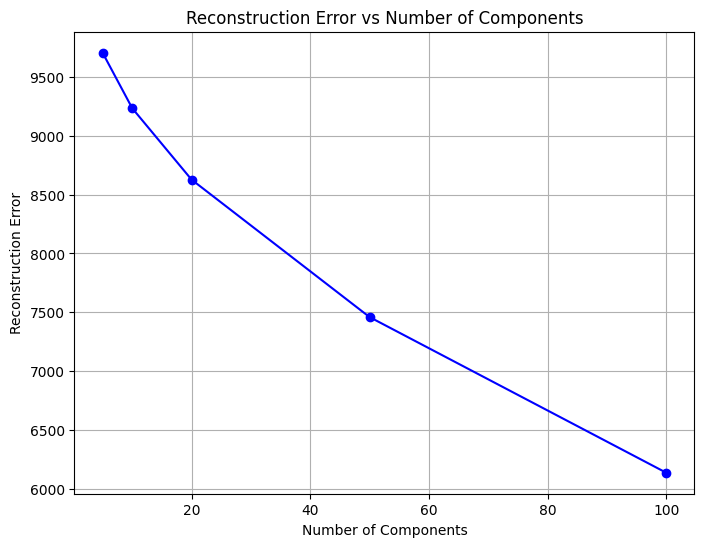

In [43]:
# Plot the final reconstruction error as a function of n_components
plot_reconstruction_error(reconstruction_errors_dict)

The plot confirms that as the number of components the amount of error decreases (the amount of compression) as it is written in the assignment description. Since we are using "small" number of components the error is quite high and this will decrease the accuracy of our recommendation system. We expect the max number of components are going to have the best accuracy. Now, we will find the best number of components to confirm that statement.

In [44]:
# Step 3: Get training accuracies

# Declare some list of thresholds to try
list_thr = [0.1, 0.2, 0.3, 0.4, 0.5]  # Define thresholds
best_accuracy = 0
best_component = 0
best_t = 0
best_reconstruction = 0

mask_train_data = ~np.isnan(train_data) 

for component in list_components:
    W, H, _ = reconstruction_errors_dict[component]
    
    # Compute the reconstruction matrix
    reconstruction_matrix = np.dot(W, H) 

    
    for t in list_thr:
        # Threshold the NMF reconstruction
        predictions = predict(reconstruction_matrix, t)

        # Compute accuracy using the mask and actual 'is_like' values
        accuracy = accuracy_score(predictions, train_data,  mask_train_data)

        if (accuracy > best_accuracy):
            best_accuracy = accuracy
            best_component = component
            best_t = t
            best_reconstruction = reconstruction_matrix

        print(f"Accuracy for component {component} and threshold {t}: {accuracy:.2f}%")

        # Output the result for the current component and threshold
print(f"\nBest accuracy for component {best_component} and threshold {best_t}: {best_accuracy:.2f}%")

Accuracy for component 5 and threshold 0.1: 84.29%
Accuracy for component 5 and threshold 0.2: 83.19%
Accuracy for component 5 and threshold 0.3: 82.65%
Accuracy for component 5 and threshold 0.4: 82.44%
Accuracy for component 5 and threshold 0.5: 82.32%
Accuracy for component 10 and threshold 0.1: 85.38%
Accuracy for component 10 and threshold 0.2: 84.13%
Accuracy for component 10 and threshold 0.3: 83.30%
Accuracy for component 10 and threshold 0.4: 82.88%
Accuracy for component 10 and threshold 0.5: 82.63%
Accuracy for component 20 and threshold 0.1: 86.77%
Accuracy for component 20 and threshold 0.2: 85.39%
Accuracy for component 20 and threshold 0.3: 84.31%
Accuracy for component 20 and threshold 0.4: 83.69%
Accuracy for component 20 and threshold 0.5: 83.29%
Accuracy for component 50 and threshold 0.1: 89.22%
Accuracy for component 50 and threshold 0.2: 87.66%
Accuracy for component 50 and threshold 0.3: 86.39%
Accuracy for component 50 and threshold 0.4: 85.57%
Accuracy for comp

As expected, with max number of components we achieve the best accuracy. Now, we will try different values for the threshold to find its best value. We try on the provided validation set.

In [24]:
# Step 4: Get validation accuracies
# This is where we fit the n_components and the threshold
list_thr = [0.1, 0.2, 0.3, 0.4, 0.5]
best_accuracy = 0
best_component = 0
best_t = 0
best_reconstruction = 0

mask_val_data = ~np.isnan(val_data)  

for component in list_components:
    W, H, _ = reconstruction_errors_dict[component]
    
    # Compute the reconstruction matrix
    reconstruction_matrix = np.dot(W, H) 
    
    
    for t in list_thr:
        # Threshold the NMF reconstruction
        predictions = predict(reconstruction_matrix, t)
        
        accuracy = accuracy_score(predictions, val_data, mask_val_data)

        if (accuracy > best_accuracy):
            best_accuracy = accuracy
            best_component = component
            best_t = t
            best_reconstruction = reconstruction_matrix

        print(f"Accuracy for component {component} and threshold {t}: {accuracy:.2f}%")

        # Output the result for the current component and threshold
print(f"\nBest accuracy for component {best_component} and threshold {best_t}: {best_accuracy:.2f}%")

Accuracy for component 5 and threshold 0.1: 83.57%
Accuracy for component 5 and threshold 0.2: 82.91%
Accuracy for component 5 and threshold 0.3: 82.73%
Accuracy for component 5 and threshold 0.4: 82.73%
Accuracy for component 5 and threshold 0.5: 82.70%
Accuracy for component 10 and threshold 0.1: 83.77%
Accuracy for component 10 and threshold 0.2: 83.06%
Accuracy for component 10 and threshold 0.3: 82.86%
Accuracy for component 10 and threshold 0.4: 82.79%
Accuracy for component 10 and threshold 0.5: 82.70%
Accuracy for component 20 and threshold 0.1: 83.70%
Accuracy for component 20 and threshold 0.2: 83.23%
Accuracy for component 20 and threshold 0.3: 82.95%
Accuracy for component 20 and threshold 0.4: 82.79%
Accuracy for component 20 and threshold 0.5: 82.71%
Accuracy for component 50 and threshold 0.1: 83.19%
Accuracy for component 50 and threshold 0.2: 83.06%
Accuracy for component 50 and threshold 0.3: 82.91%
Accuracy for component 50 and threshold 0.4: 82.74%
Accuracy for comp

Finally, we use the found best number of components and recommendation threshold on the test data. We compute the test accuracy.

In [34]:
# Step 5: Get the final test accuracy
# We use the n_components and the threshold we fit on the validation set

# Compute test accuracy
W, H, _ = reconstruction_errors_dict[best_component]

 # Compute the reconstruction matrix
reconstruction_matrix = np.dot(W, H) 
mask_test_data = ~np.isnan(test_data) 

print(reconstruction_matrix[mask_test_data][:10])
print(test_data[mask_test_data][:100])

# Predict the 'is_like' values
predictions_test = predict(reconstruction_matrix, best_t)

print(predictions_test[mask_test_data][:100])

# Compute accuracy using the mask and actual 'is_like' values
test_accuracy = accuracy_score(predictions_test, test_data, mask_test_data)

print(f"Test accuracy: {test_accuracy:.2f}%, thr: {best_t:g}, n_components: {best_component}")

[0.00000000e+00 0.00000000e+00 0.00000000e+00 1.84568694e-44
 3.92092957e-62 1.27435919e-03 9.84105144e-05 4.41720383e-04
 0.00000000e+00 0.00000000e+00]
[1. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0.
 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 0. 1. 0.]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Test accuracy: 78.69%, thr: 0.1, n_components: 10


The calculated accuracy of 78.69% we consider to be fair, since we do not do anything extra as to calculating extra features and we just follow the basic steps suggested in the assignment. TO improve the accuracy, we can add extra features as "is match" where if two people liked each other, they are considered a match and many more such features. Moreover, we can increase the number of components or/and the number of iterations as this will make the error even less, but this is going to be so computationally expensive. 

## Distance-based recommender system
Here, we define some helper methods to calculate the Min-hash of the interactions of each user to find people with similar preferences. We compute Jaccard distance for the columns to retrieve a top-k. We also use user-user and item-item interactions and use the mean as an aggreagation function.

In [ ]:
# Use min-hashing on the rows and find the nearest neighbors using Jaccard distance

# Use min-hashing on the columns and find the nearest neighbors using Jaccard distance

def combined_similarity(signature1, signature2):
    # AND/OR construction
    and_similarity = np.mean(signature1 == signature2)
    or_similarity = np.mean(np.logical_or(signature1 == signature2, signature1 != signature2))
    
    return (and_similarity + or_similarity) / 2

def jaccard_similarity(set1, set2):
    # If both sets are empty, return 1.0
    if not set1 and not set2:
        return 1.0
    
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))

    if union == 0:
        return 0.0
    
    return intersection / union

def find_nearest_neighbors(signatures, ids, k):
    num_hashes, num_ids = signatures.shape
    neighbors = []
    # For each id, find the k nearest neighbors
    for i in range(num_ids):
        similarities = []
        for j in range(num_ids):
            if i != j:
                # Compute the Jaccard similarity between the two sets
                #similarity = combined_similarity(signatures[:, i], signatures[:, j])
                similarity = jaccard_similarity(ids[i], ids[j])
                similarities.append((j, similarity))

        # Sort the similarities in descending order
        similarities.sort(key=lambda x: x[1], reverse=True)
        neighbors.append([idx for idx, sim in similarities[:k]])

    return neighbors

# Example usage
train_data = np.load('train_data.npy')
test_data = np.load('test_data.npy')
val_data = np.load('val_data.npy')

num_hashes = 100
num_neighbors = 5
hashes = [HashFunction(np.random.randint(1, 1000), np.random.randint(0, 1000)) for _ in range(num_hashes)]

# Assuming train_data is already loaded and is a numpy array
user_ids = [set(np.where(row > 0)[0]) for row in train_data]
item_ids = [set(np.where(col > 0)[0]) for col in train_data.T]

user_signatures = compute_signature(hashes, user_ids)
item_signatures = compute_signature(hashes, item_ids)

user_neighbors = find_nearest_neighbors(user_signatures, user_ids, num_neighbors)
item_neighbors = find_nearest_neighbors(item_signatures, item_ids, num_neighbors)

In [550]:
# Aggregate the user-user and item-item nearest neighbor information to estimate recommendations

def aggregate_recommendations(user_neighbors, item_neighbors, train_data):
    num_users, num_items = train_data.shape
    recommendations = np.zeros((num_users, num_items))

    for user in range(num_users):
        for item in range(num_items):
            # Get the similarities for the user and item
            user_similarities = [train_data[neighbor, item] for neighbor in user_neighbors[user] 
                                 if neighbor < num_users and train_data[neighbor, item] > 0]
            item_similarities = [train_data[user, neighbor] for neighbor in item_neighbors[item] 
                                 if neighbor < num_items and train_data[user, neighbor] > 0]

            # if user_similarities:
            #     recommendations[user, item] += np.mean(user_similarities)
            # if item_similarities:
            #     recommendations[user, item] += np.mean(item_similarities)

            # # Aggregate the recommendations
            if user_similarities:
                recommendations[user, item] += np.sum(user_similarities) / (len(user_similarities) + 1e-6)
            if item_similarities:
                recommendations[user, item] += np.mean(item_similarities) / (len(item_similarities) + 1e-6)

    return recommendations

recommendations = aggregate_recommendations(user_neighbors, item_neighbors, train_data)

From the accuracy results above we can make the conclusion that using more near neighbors could improve the accuracy while using more hash functions doesn't necessarily lead to more accurate results. However, (at least for me) using too many hash functions or NNs is taxing on the time it takes to cross validate. We need to use K-fold cross-validation with small numnber of k to create bands. We compare bands to bands. We do not have missing values, so leave-one-out cross-validation is less suitable for our instance and more computationally heavy.

In [195]:
# Cross-validate on the validation data: number of hash functions and number of neighbors
# (As we did for NMF above, for the n_components and the threshold.)

def cross_validate(hashes, train_data, val_data, num_hashes_list, top_k_list):
    results = []
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    for num_hashes in num_hashes_list:
        # Generate random hash functions
        current_hashes = [HashFunction(np.random.randint(1, 1000), np.random.randint(0, 1000)) for _ in range(num_hashes)]
        for top_k in top_k_list:
            accuracy_list = []

            for train_index, val_index in kf.split(train_data):
                train_fold = train_data[train_index]  # Convert to NumPy array
                val_fold = val_data[val_index]

                user_ids = [set(np.where(row > 0)[0]) for row in train_fold]
                item_ids = [set(np.where(col > 0)[0]) for col in train_fold.T]

                # Compute the MinHash signatures for both users and items
                print(f"Using {num_hashes} hash functions and top {top_k} neighbors")
                user_signatures = compute_signature(current_hashes, user_ids)
                item_signatures = compute_signature(current_hashes, item_ids)

                # Find the nearest neighbors for both users and items
                user_neighbors = find_nearest_neighbors(user_signatures, user_ids, top_k)
                item_neighbors = find_nearest_neighbors(item_signatures, item_ids, top_k)

                recommendations = aggregate_recommendations(user_neighbors, item_neighbors, val_fold)

                # Compute the accuracy of the recommendations
                # Evaluate using classification accuracy
                valid_mask = ~np.isnan(val_fold)
                pred_is_like = (recommendations > 0.5).astype(int)
                accuracy = accuracy_score(pred_is_like, val_fold, valid_mask)
                accuracy_list.append(accuracy)

            avg_accuracy = np.mean(accuracy_list)
            results.append((num_hashes, top_k, avg_accuracy))

    return results

In [196]:
num_hashes_list = [10, 30, 100]  # Set the number of hash functions for cross-validation
top_k_list = [1, 3, 5]  # Set the number of neighbors for cross-validation

results = cross_validate(hashes, train_data, val_data, num_hashes_list, top_k_list)

# Convert results to a DataFrame for better visualization
results_df = pd.DataFrame(results, columns=['Num Hashes', 'Top K', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)
print(results_df)

best_num_hashes, best_top_k, best_accuracy = results_df.iloc[0]

Using 10 hash functions and top 1 neighbors
Using 10 hash functions and top 1 neighbors
Using 10 hash functions and top 1 neighbors
Using 10 hash functions and top 1 neighbors
Using 10 hash functions and top 1 neighbors
Using 10 hash functions and top 3 neighbors
Using 10 hash functions and top 3 neighbors
Using 10 hash functions and top 3 neighbors
Using 10 hash functions and top 3 neighbors
Using 10 hash functions and top 3 neighbors
Using 10 hash functions and top 5 neighbors
Using 10 hash functions and top 5 neighbors
Using 10 hash functions and top 5 neighbors
Using 10 hash functions and top 5 neighbors
Using 10 hash functions and top 5 neighbors
Using 30 hash functions and top 1 neighbors
Using 30 hash functions and top 1 neighbors
Using 30 hash functions and top 1 neighbors
Using 30 hash functions and top 1 neighbors
Using 30 hash functions and top 1 neighbors
Using 30 hash functions and top 3 neighbors
Using 30 hash functions and top 3 neighbors
Using 30 hash functions and top 

We find that with the validation set the best accuracy is made with more neighbours considered. The number of hash functions is less important, since the accuracy is the same with equal amount of neighbours but different number of hash functions. Finally, we compute the predictions using the test data and we calculate its accuracy.

In [198]:
# Retrain with the best parameters
final_hashes = [HashFunction(np.random.randint(1, 1000), np.random.randint(0, 1000)) for _ in range(int(best_num_hashes))]

user_signatures = compute_signature(final_hashes, user_ids)
item_signatures = compute_signature(final_hashes, item_ids)

# Find neighbors for users and items using the best top_k
user_neighbors = find_nearest_neighbors(user_signatures, user_ids, int(best_top_k))
item_neighbors = find_nearest_neighbors(item_signatures, item_ids, int(best_top_k))

# Generate recommendations on the test data
test_recommendations = aggregate_recommendations(user_neighbors, item_neighbors, test_data)

# Predict "is_like" on test set (thresholding at 0.5)
test_predictions = (test_recommendations > 0.5).astype(int)

# Ignore nan values
valid_mask = ~np.isnan(test_data)

accuracy = accuracy_score(test_predictions, test_data, valid_mask)
print(f"Test accuracy: {accuracy:.2f}%")

Test accuracy: 78.11%


The accuracy of 78.11% is comparable with the one of NMF algorithm. It is worth trying with higher number of neighbours, which may increase the accuracy, but will be computationally expensive. To sum up all, we consider the NMF algorithm superior, because of its ability to handle missing data (data imputation). However, Min-hashing is not dependent on the data provided and it works great with people that have had many connections will others and with people that are new to the system (Min- hashing do not suffer from the "cold start problem"). 